# Clase 5 · Probabilidad e inferencia: ¿real o azar?

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

**Descriptiva e inferencia.** En las clases 2 a 4 hicimos estadística descriptiva: resumir y graficar la tabla que tenemos, con números que hablan solo de esas filas. La **inferencia estadística** usa esos mismos datos para hablar de la población de la que salieron, y dice cuánta incertidumbre trae esa afirmación. Hace dos preguntas: ¿cuánto vale? (estimación, con un intervalo) y ¿es real o azar? (prueba de hipótesis, con un valor p). La probabilidad es el lenguaje de esa incertidumbre; por eso va primero.

**Por qué aparece la distribución normal.** No porque los datos sean normales (la duración de los viajes no lo es), sino porque los promedios lo son: si repitiéramos la muestra muchas veces, la media y la pendiente se repartirían como una campana alrededor del valor real (el teorema central del límite, sección 3). De esa campana sale el 1,96 que construye el intervalo de confianza y el valor p.

**El hilo de la clase:** todo número que sale de una muestra se mueve de muestra en muestra. Inferir es medir ese movimiento (el error estándar) y usarlo de dos formas: como rango (el intervalo de confianza) y como contraste (la prueba de hipótesis y el valor p). Primero con la media de la duración, donde podemos ver el movimiento porque tenemos la población; después con la pendiente de las comunas, donde lo vemos remuestreando (bootstrap) y con la fórmula de statsmodels. Al final, la trampa de probar de todo y otro modelo, la regresión logística, que se lee con el mismo summary.

**La pregunta de la clase:** ¿cuánto se movería este número con otra muestra?

## 1. Preparación

Hoy la EOD cumple un papel nuevo: trataremos sus 113 mil viajes **como si fueran la población completa** de viajes de Santiago. Es una ficción didáctica, pero permite hacer lo que en la realidad nunca se puede: tomar muchas muestras de la población y mirar cómo cambian los resultados entre una y otra. Por lo mismo, en esta parte no ponderamos: la población es la tabla tal cual.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
# scipy.stats: las distribuciones de probabilidad con nombre
from scipy import stats

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Si clonó el repositorio del curso, los datos ya están en su disco:
# BASE = "datos/eod_stgo/"

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)

# La población de hoy: la duración de cada viaje, sin faltantes ni ceros
duracion = viajes["TiempoViaje"].dropna()
duracion = duracion[duracion > 0]
len(duracion)

113113

## 2. El azar tiene forma: variables aleatorias y distribuciones

**Objetivo:** ponerle nombre a algo que ya usamos: la duración de un viaje es una **variable aleatoria**, y su histograma es su **distribución**.

Una variable aleatoria es una cantidad cuyo valor depende del azar: la duración del próximo viaje que registre la encuesta puede ser 10 minutos o 90, y no lo sabemos de antemano. Su **distribución** dice qué valores puede tomar y con qué frecuencia; para una población completa, es exactamente el histograma. Y la **esperanza** $E[X]$ es la media de esa distribución: el valor promedio que esperaríamos a la larga. La **varianza** mide cuánto se dispersa alrededor de la esperanza. Son los mismos resúmenes de la clase 2, ahora vistos como propiedades de la población y no de una muestra.

In [4]:
print("Esperanza (media poblacional):", round(duracion.mean(), 2), "min")
print("Mediana:", duracion.median(), "min")
print("Desviación estándar:", round(duracion.std(), 2), "min")
print("Asimetría:", round(duracion.skew(), 2))

Esperanza (media poblacional): 36.93 min
Mediana: 30.0 min
Desviación estándar: 36.05 min
Asimetría: 5.3


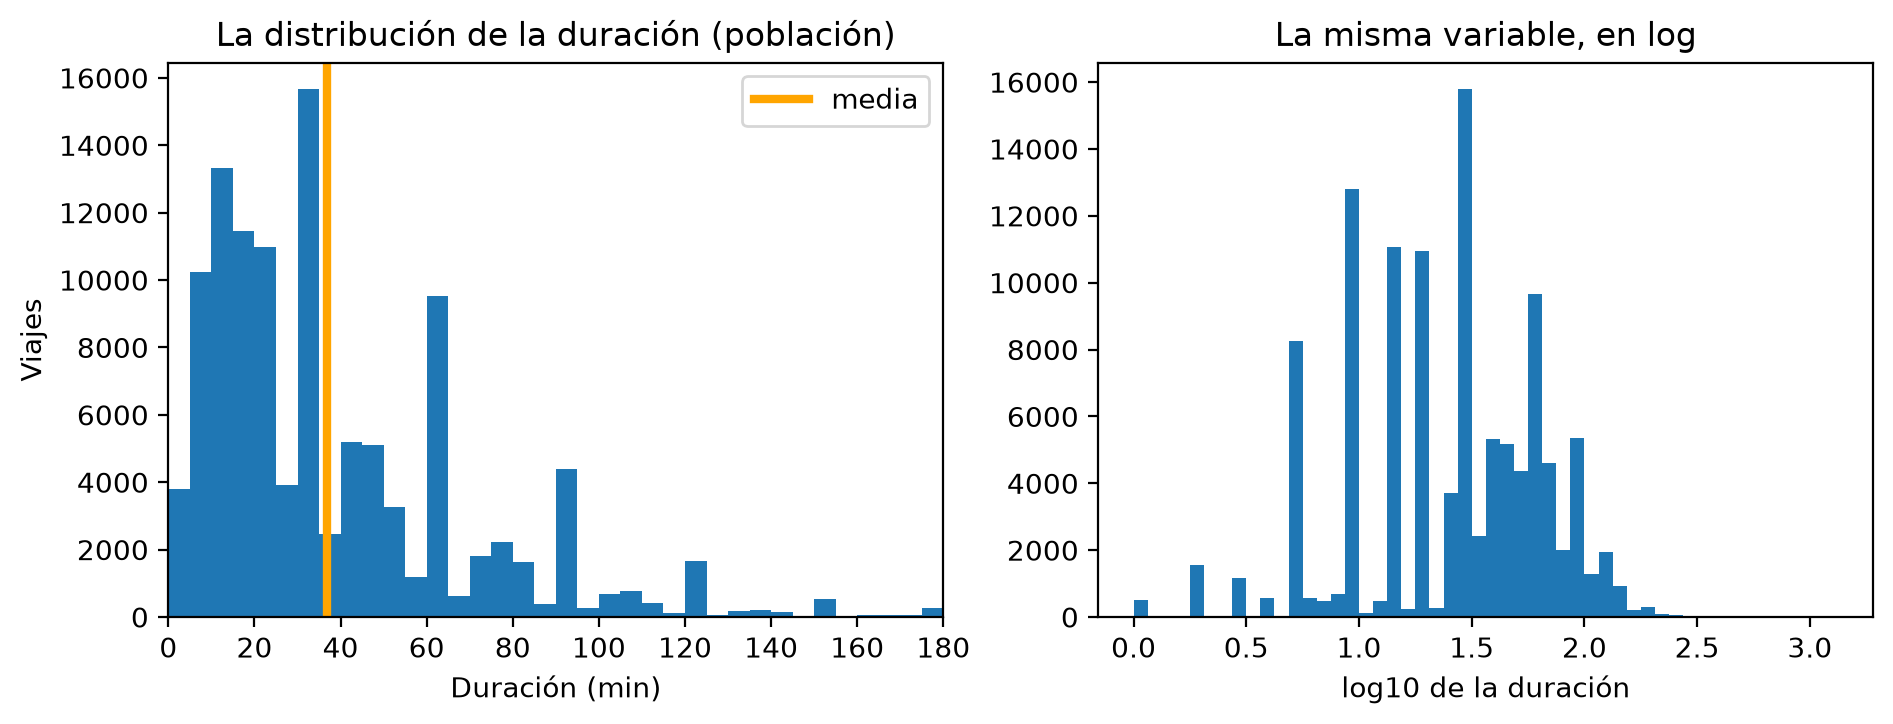

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(duracion, bins=range(0, 181, 5))
axes[0].axvline(duracion.mean(), color="orange", lw=3, label="media")
axes[0].set(xlim=(0, 180), xlabel="Duración (min)", ylabel="Viajes",
            title="La distribución de la duración (población)")
axes[0].legend()
axes[1].hist(np.log10(duracion), bins=50)
axes[1].set(xlabel="log10 de la duración", title="La misma variable, en log")
plt.show()

Hay otra variable aleatoria que nos va a importar más que la duración de un viaje: la **media de 100 viajes tomados al azar**, que depende de qué viajes cayeron en la muestra. Su distribución, como veremos en la sección 3, tiene forma de campana. Y esa campana tiene nombre.

### Las distribuciones con nombre

Algunas formas aparecen tanto que tienen nombre y fórmula. La más importante es la **normal**, $X \sim N(\mu, \sigma^2)$: la campana simétrica, definida por dos parámetros: $\mu$, la media (el centro de la campana), y $\sigma$, la desviación estándar (su ancho). Su regla práctica: el 68% de los valores cae a menos de una $\sigma$ de la media, el 95% a menos de $1{,}96\,\sigma$ y el 99,7% a menos de $3\sigma$. La normal importa aquí no porque los datos la sigan, sino porque, como veremos en la sección 3, los promedios la siguen. Ese 1,96 va a reaparecer en los intervalos de confianza.

La duración en minutos no es normal (cola larga, asimetría 5,3), pero en log se parece bastante. Comparemos cada histograma con la normal que tiene su misma media y desviación:

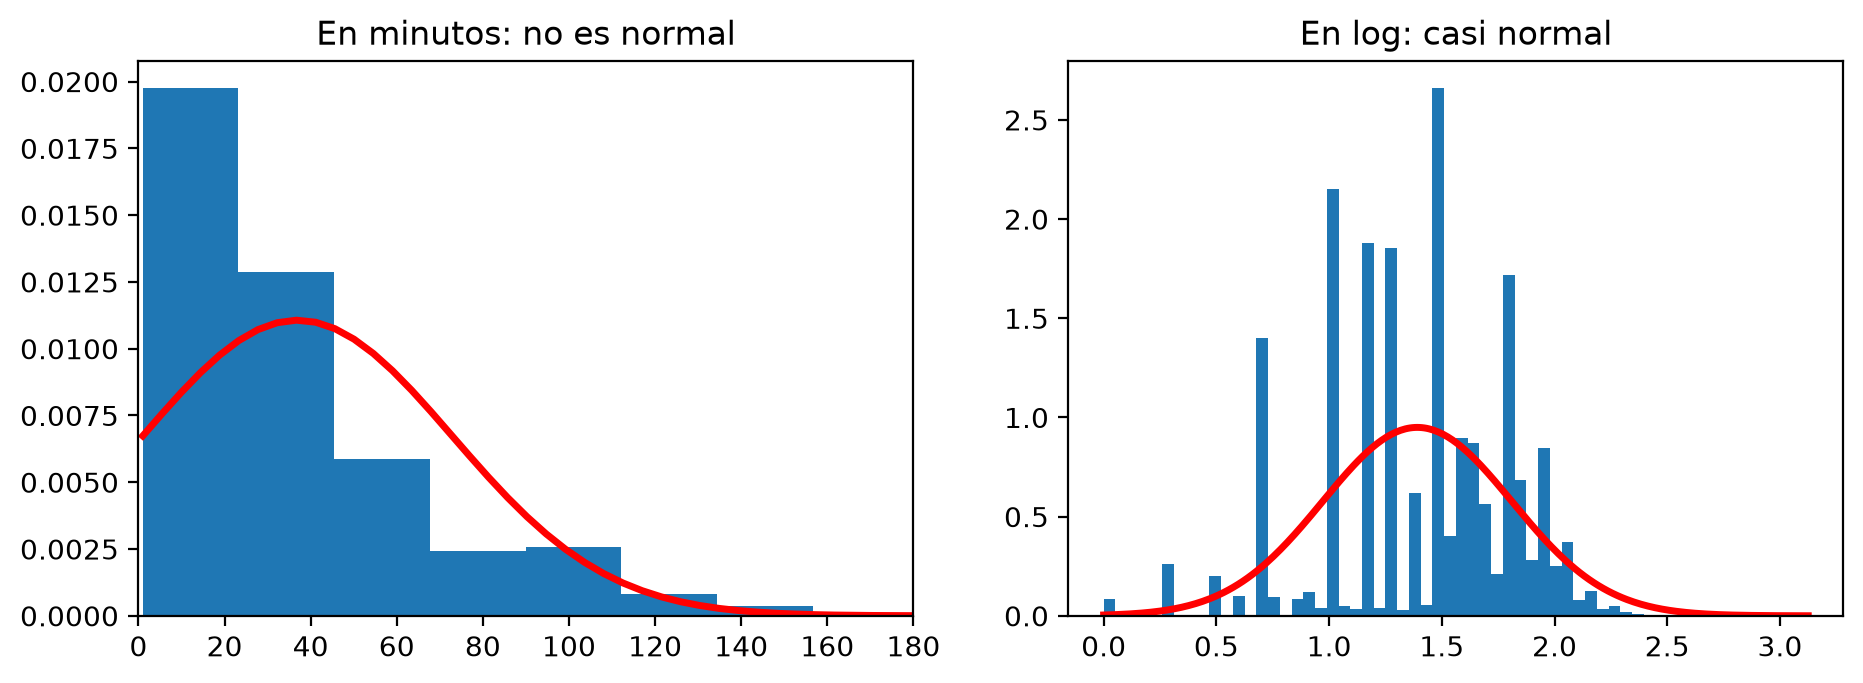

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, x, titulo in [(axes[0], duracion, "En minutos: no es normal"),
                      (axes[1], np.log10(duracion), "En log: casi normal")]:
    ax.hist(x, bins=60, density=True)
    grilla = np.linspace(x.min(), x.max(), 300)
    # stats.norm.pdf: la curva de la normal con esa media y esa sd
    ax.plot(grilla, stats.norm.pdf(grilla, x.mean(), x.std()), color="red", lw=2.5)
    ax.set_title(titulo)
axes[0].set_xlim(0, 180)
plt.show()

Esto explica dos cosas de la clase 4: por qué el log ayudó a la regresión (en log la variable se comporta como una normal) y por qué la normal aparece en todas partes: cuando muchas causas pequeñas se suman, el resultado tiende a ser normal. Eso último es un teorema, y lo veremos actuar en la próxima sección.

## 3. Un número se mueve: la distribución muestral

**Objetivo:** ver con los propios ojos cuánto cambia un resultado (la media) de una muestra a otra.

En la vida real solo tenemos una muestra. Aquí tenemos la población, así que podemos tomar una muestra de 100 viajes, calcular su media, y repetirlo:

In [7]:
# Un generador de números aleatorios con semilla: los resultados se repiten
rng = np.random.default_rng(42)

for i in range(5):
    muestra = rng.choice(duracion, 100)
    print(f"muestra {i + 1}: media = {muestra.mean():.1f} min")
print("media de la población:", round(duracion.mean(), 1))

muestra 1: media = 33.8 min
muestra 2: media = 37.9 min
muestra 3: media = 36.9 min
muestra 4: media = 40.2 min
muestra 5: media = 36.6 min
media de la población: 36.9


Cada muestra da una media distinta, y ninguna es exactamente la poblacional. ¿Cuánto se mueven? Tomemos 2.000 muestras y miremos el histograma de sus medias: esa es la **distribución muestral** de la media, y su desviación estándar se llama **error estándar**:

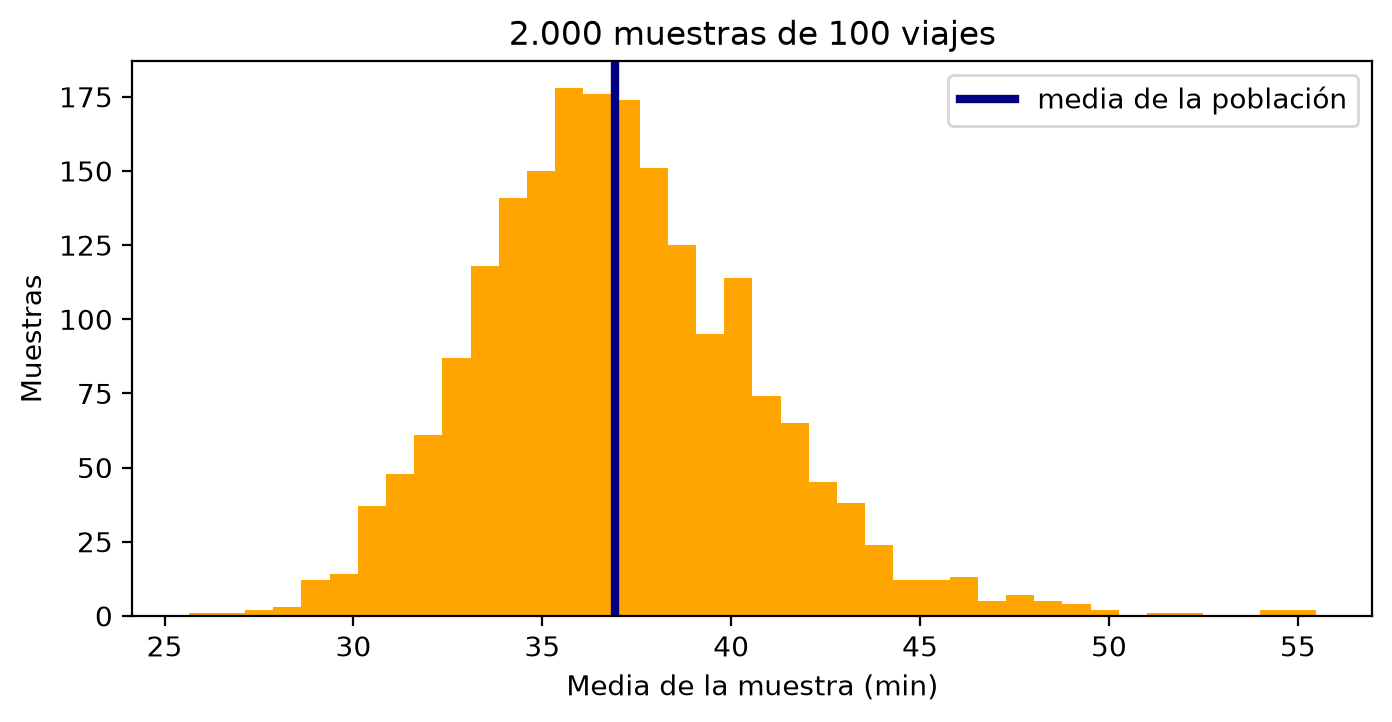

Error estándar (sd de las medias): 3.73
sigma / raíz de n: 3.6


In [8]:
medias = np.array([rng.choice(duracion, 100).mean() for _ in range(2000)])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(medias, bins=40, color="orange")
ax.axvline(duracion.mean(), color="navy", lw=3, label="media de la población")
ax.set(xlabel="Media de la muestra (min)", ylabel="Muestras",
       title="2.000 muestras de 100 viajes")
ax.legend()
plt.show()

print("Error estándar (sd de las medias):", round(medias.std(), 2))
print("sigma / raíz de n:", round(duracion.std() / np.sqrt(100), 2))

Los dos números coinciden, y esa es la fórmula del **error estándar** de la media:

$$EE(\bar{x}) = \frac{\sigma}{\sqrt{n}} \approx \frac{s}{\sqrt{n}}$$

donde $\sigma$ es la desviación estándar de la población y $n$ el tamaño de la muestra. **Decisión:** $\sigma$ no la conocemos, porque es de la población; la reemplazamos por $s$, la desviación de la muestra. Con $n$ grande da lo mismo; con $n$ chico, casi (de eso se encarga la $t$ de Student, en la sección 6). El error estándar dice cuánto se mueve la media de una muestra a otra, y que para reducirla a la mitad hay que cuadruplicar la muestra.

### El teorema central del límite

**Objetivo:** ver por qué la distribución muestral tiene forma de normal aunque la duración no la tenga.

Repitamos el experimento con muestras de 30, 100 y 500 viajes, y sobre cada histograma dibujemos la normal con media poblacional y desviación $\sigma/\sqrt{n}$:

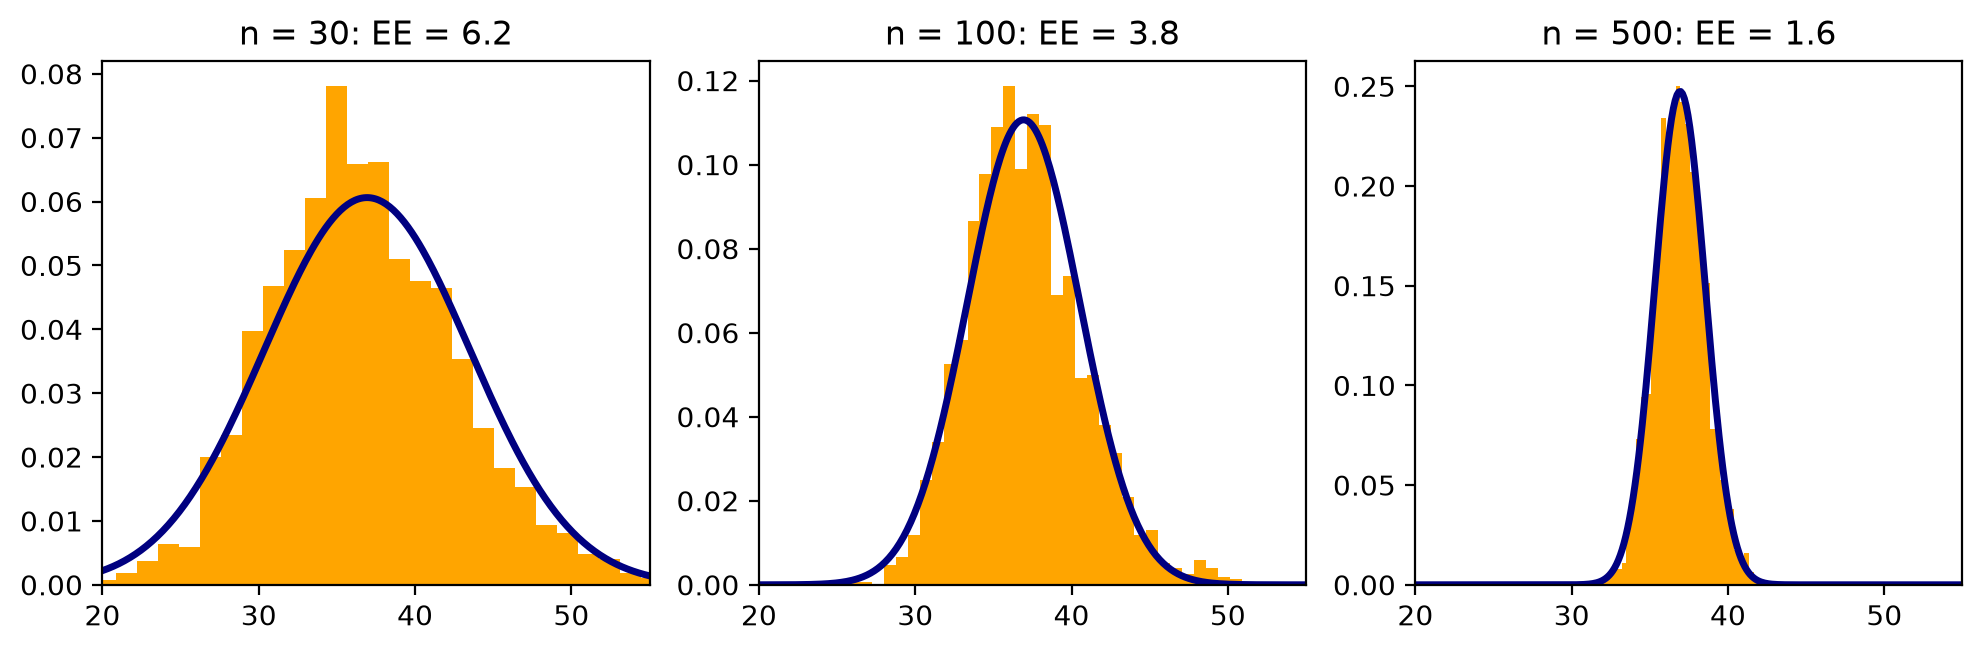

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for ax, n in zip(axes, [30, 100, 500]):
    medias_n = np.array([rng.choice(duracion, n).mean() for _ in range(2000)])
    ax.hist(medias_n, bins=40, density=True, color="orange")
    grilla = np.linspace(20, 55, 300)
    ax.plot(grilla, stats.norm.pdf(grilla, duracion.mean(), duracion.std() / np.sqrt(n)),
            color="navy", lw=2.5)
    ax.set(xlim=(20, 55), title=f"n = {n}: EE = {medias_n.std():.1f}")
plt.show()

Eso es el **teorema central del límite**: la media de una muestra se distribuye aproximadamente normal alrededor de la media de la población, con desviación $\sigma/\sqrt{n}$, **aunque la variable original no sea normal** (la duración tiene una cola larguísima y aun así las medias son una campana). Con $n$ pequeño la aproximación es más gruesa; con $n$ grande es casi perfecta. Por eso la normal es la distribución de la inferencia: no porque los datos sean normales, sino porque los promedios lo son.

## 4. Primer uso del error estándar: el intervalo de confianza

**Objetivo:** convertir el error estándar en un rango honesto para la media de la población, a partir de una sola muestra.

El puente tiene dos pasos. **Paso 1:** por el teorema central del límite las medias muestrales son normales, así que la regla de la normal se les aplica: el 95% de las medias muestrales cae a menos de $1{,}96$ errores estándar de la media real. Lo comprobamos con las 2.000 medias de la sección anterior:

In [10]:
ee_teorico = duracion.std() / np.sqrt(100)
dentro = np.abs(medias - duracion.mean()) <= 1.96 * ee_teorico
print(f"Medias muestrales a menos de 1,96 EE de la media real: {dentro.mean():.1%}")

Medias muestrales a menos de 1,96 EE de la media real: 95.0%


**Paso 2** es decir la misma frase al revés: si la media de mi muestra está a menos de 1,96 EE de la media real, entonces la media real está a menos de 1,96 EE de la media de mi muestra. Como eso pasa en el 95% de las muestras, el rango

$$\bar{x} \pm 1{,}96 \cdot \frac{s}{\sqrt{n}}$$

atrapa a la media de la población en el 95% de las muestras. Aquí $\bar{x}$ es la media de la muestra, $s/\sqrt{n}$ su error estándar (con $s$ en lugar de $\sigma$, porque en la práctica no conocemos la población) y 1,96 el múltiplo de la normal que deja 95% al centro. Ese rango es el **intervalo de confianza del 95%**. Con una muestra de 100 viajes:

In [11]:
muestra = rng.choice(duracion, 100)
ee = muestra.std(ddof=1) / np.sqrt(100)
inferior, superior = muestra.mean() - 1.96 * ee, muestra.mean() + 1.96 * ee

print(f"media de la muestra: {muestra.mean():.1f} | EE: {ee:.2f}")
print(f"intervalo del 95%: [{inferior:.1f}, {superior:.1f}]")
print(f"media de la población: {duracion.mean():.1f} -> ¿cae dentro? {inferior <= duracion.mean() <= superior}")

media de la muestra: 38.2 | EE: 3.68
intervalo del 95%: [31.0, 45.4]
media de la población: 36.9 -> ¿cae dentro? True


La lectura correcta del 95% es sobre el **procedimiento**, no sobre este intervalo en particular: si repitiéramos el muestreo muchas veces, el 95% de los intervalos atraparía la media real. Como tenemos la población, lo podemos comprobar:

In [12]:
atrapan = 0
for _ in range(1000):
    m = rng.choice(duracion, 100)
    ee = m.std(ddof=1) / 10
    if m.mean() - 1.96 * ee <= duracion.mean() <= m.mean() + 1.96 * ee:
        atrapan += 1
print("Intervalos que atrapan la media real:", atrapan, "de 1000")

Intervalos que atrapan la media real: 925 de 1000


Cerca del 95% (un poco menos: con $n = 100$ y una variable de cola tan larga, la aproximación normal todavía es algo gruesa; con $n$ mayor se acerca al 95% exacto). Dibujemos 100 de esos intervalos:

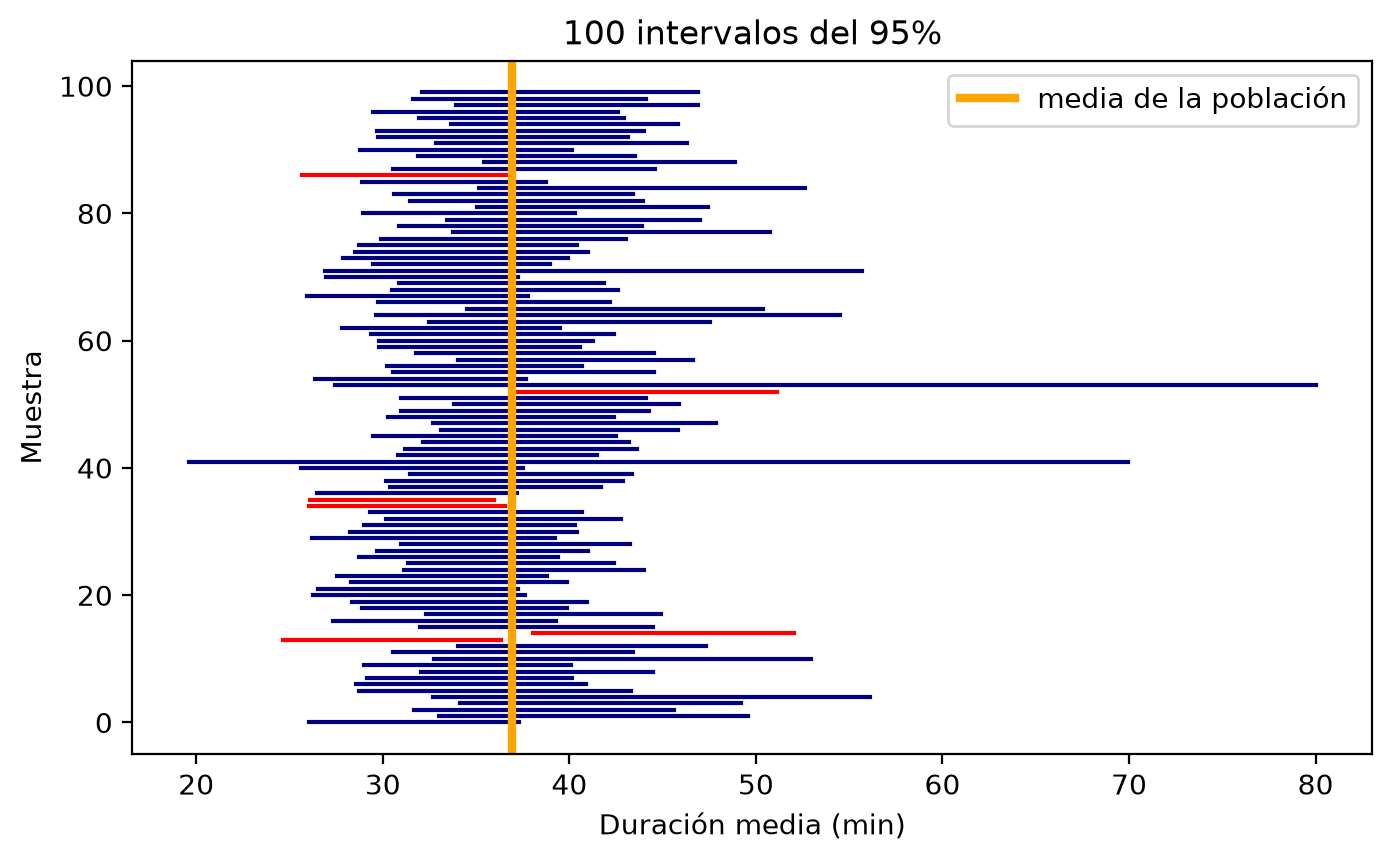

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i in range(100):
    m = rng.choice(duracion, 100)
    ee = m.std(ddof=1) / 10
    inferior, superior = m.mean() - 1.96 * ee, m.mean() + 1.96 * ee
    atrapa = inferior <= duracion.mean() <= superior
    ax.plot([inferior, superior], [i, i], color="navy" if atrapa else "red", lw=1.5)
ax.axvline(duracion.mean(), color="orange", lw=3, label="media de la población")
ax.set(xlabel="Duración media (min)", ylabel="Muestra", title="100 intervalos del 95%")
ax.legend()
plt.show()

## 5. La pendiente también se mueve: bootstrap

**Objetivo:** ver cuánto se movería la pendiente de las comunas con otra muestra, y entender el error estándar que statsmodels imprime.

La pregunta pendiente desde la clase 3: la duración media de los viajes baja 4,8 minutos por cada millón de ingreso medio de la comuna, con 45 comunas. Esa pendiente es un número que sale de una muestra, igual que la media de 100 viajes: con otras comunas saldría otra. Pero aquí no hay una población de comunas de donde sacar otra muestra. Reconstruimos la tabla por comuna de la clase 3 (ponderada, como entonces):

In [14]:
viajes_final = viajes.merge(hogares[["Hogar", "Comuna", "IngresoHogar"]], on="Hogar")
viajes_final = viajes_final.dropna(subset=["FactorLaboralNormal", "TiempoViaje", "IngresoHogar"]).copy()
w = viajes_final["FactorLaboralNormal"]
viajes_final["w_ingreso"] = w * viajes_final["IngresoHogar"]
viajes_final["w_duracion"] = w * viajes_final["TiempoViaje"]
suma = viajes_final.groupby("Comuna").sum(numeric_only=True)
por_comuna = pd.DataFrame({
    "ingreso": suma["w_ingreso"] / suma["FactorLaboralNormal"] / 1e6,
    "duracion": suma["w_duracion"] / suma["FactorLaboralNormal"],
    "n": viajes_final.groupby("Comuna").size()}).reset_index()
por_comuna = por_comuna[por_comuna["n"] >= 200]
len(por_comuna)

45

El **bootstrap** imita el muestreo con la muestra que hay: toma las 45 comunas, saca 45 **con reemplazo** (algunas se repiten, otras quedan fuera), ajusta la recta, y lo repite miles de veces. La distribución de las pendientes obtenidas es una estimación de la distribución muestral de la pendiente, sin suponer nada.

¿Se puede confiar en remuestrear una sola muestra? Con la media de la duración lo podemos comprobar, porque tenemos la población: comparemos la distribución muestral real de la sección 3 (2.000 muestras distintas) con la que sale de remuestrear una sola muestra de 100 viajes:

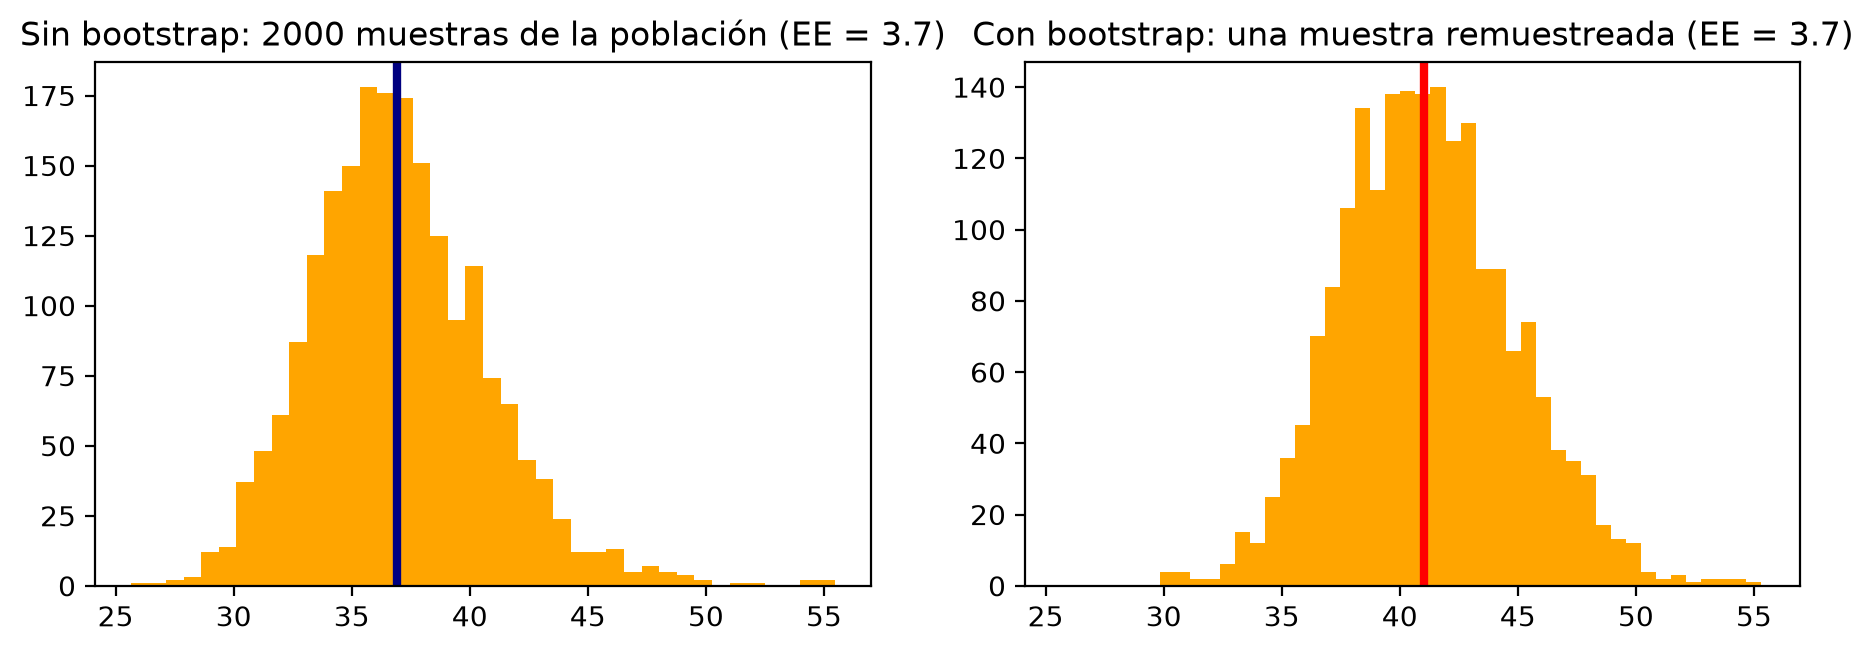

In [15]:
una_muestra = rng.choice(duracion, 100)
medias_boot = np.array([rng.choice(una_muestra, 100).mean() for _ in range(2000)])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True)
axes[0].hist(medias, bins=40, color="orange")
axes[0].axvline(duracion.mean(), color="navy", lw=3)
axes[0].set_title(f"Sin bootstrap: 2000 muestras de la población (EE = {medias.std():.1f})")
axes[1].hist(medias_boot, bins=40, color="orange")
axes[1].axvline(una_muestra.mean(), color="red", lw=3)
axes[1].set_title(f"Con bootstrap: una muestra remuestreada (EE = {medias_boot.std():.1f})")
plt.show()

Casi la misma campana y casi el mismo error estándar, obtenidos de una sola muestra. El bootstrap se centra en la media de esa muestra, no en la de la población (que en la práctica no se conoce): lo que reproduce es el ancho, y eso es lo que necesitamos. Ahora sí, la pendiente:

In [16]:
x = por_comuna["ingreso"].values
y = por_comuna["duracion"].values
b_observada = np.polyfit(x, y, 1)[0]

pendientes = []
for _ in range(2000):
    # rng.integers: 45 índices al azar, con repetición
    idx = rng.integers(0, len(x), len(x))
    pendientes.append(np.polyfit(x[idx], y[idx], 1)[0])
pendientes = np.array(pendientes)

print(f"pendiente observada: {b_observada:.2f}")
print(f"desviación de las 2000 pendientes (error estándar bootstrap): {pendientes.std():.2f}")
inferior, superior = np.percentile(pendientes, [2.5, 97.5])
print(f"intervalo bootstrap 95%: [{inferior:.2f}, {superior:.2f}]")
print(f"fracción de remuestras con pendiente >= 0: {np.mean(pendientes >= 0):.3f}")

pendiente observada: -4.81
desviación de las 2000 pendientes (error estándar bootstrap): 1.69
intervalo bootstrap 95%: [-8.82, -2.15]
fracción de remuestras con pendiente >= 0: 0.002


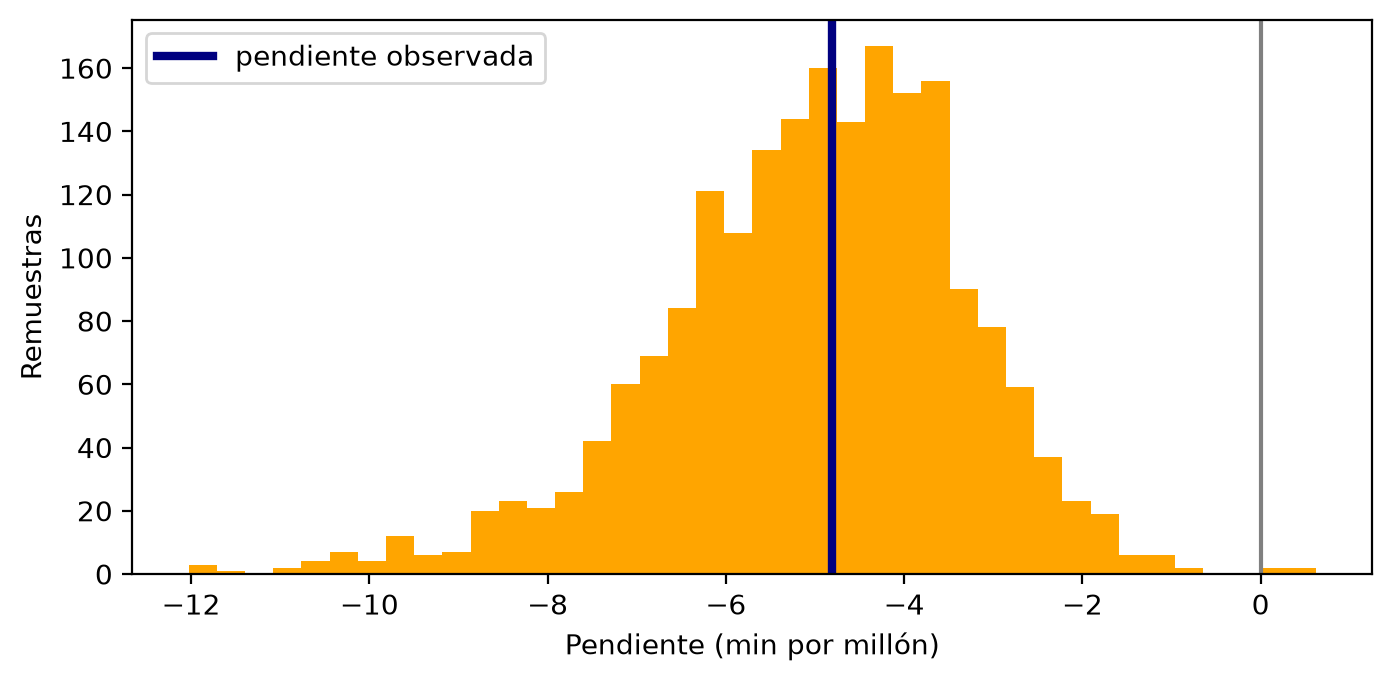

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(pendientes, bins=40, color="orange")
ax.axvline(b_observada, color="navy", lw=3, label="pendiente observada")
ax.axvline(0, color="gray", lw=1.5)
ax.set(xlabel="Pendiente (min por millón)", ylabel="Remuestras")
ax.legend()
plt.show()

Las 2.000 pendientes forman una campana alrededor de la observada (el teorema central del límite otra vez: un coeficiente es un promedio ponderado de los $y$). Su desviación es el **error estándar de la pendiente**, el mismo concepto que el de la media. Y casi ninguna remuestra llega al 0.

statsmodels calcula ese error estándar con una fórmula, a partir de los residuos y sin remuestrear: es la columna **std err** del summary que hasta ahora no leíamos:

In [18]:
modelo = sm.OLS(por_comuna["duracion"], sm.add_constant(por_comuna["ingreso"])).fit()
modelo.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,38.3352,1.773,21.622,0.000,34.760,41.911
ingreso,-4.8146,2.015,-2.389,0.021,-8.879,-0.750


Por ahora, tres columnas de la fila del ingreso:

- **coef** = −4,81: la pendiente.
- **std err** = 2,02: el error estándar de la pendiente, cerca del que dio el bootstrap.
- **[0.025, 0.975]** = [−8,9; −0,75]: el intervalo de confianza del 95% de la pendiente, coeficiente ± 2,02 · EE (2,02 en lugar de 1,96 por una razón que viene en la próxima sección). Es el primer uso del error estándar, ahora para la pendiente.

Los dos caminos, comparados:

In [19]:
intervalo_formula = modelo.conf_int().loc["ingreso"]
print(f"bootstrap: [{inferior:.2f}, {superior:.2f}]")
print(f"fórmula:   [{intervalo_formula.iloc[0]:.2f}, {intervalo_formula.iloc[1]:.2f}]")

bootstrap: [-8.82, -2.15]
fórmula:   [-8.88, -0.75]


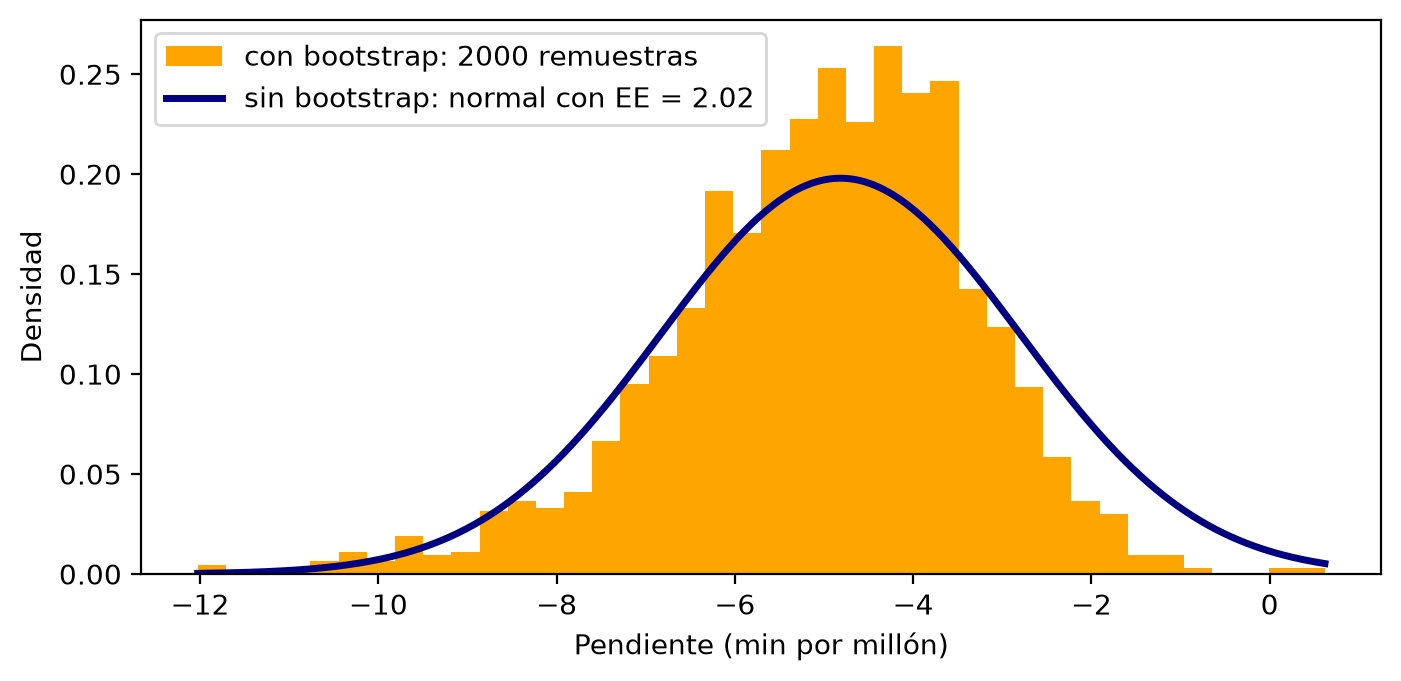

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(pendientes, bins=40, density=True, color="orange", label="con bootstrap: 2000 remuestras")
grilla = np.linspace(pendientes.min(), pendientes.max(), 300)
ee_formula = modelo.bse["ingreso"]
# stats.norm.pdf: la campana con la pendiente observada y el EE de la fórmula
ax.plot(grilla, stats.norm.pdf(grilla, b_observada, ee_formula), color="navy", lw=2.5,
        label=f"sin bootstrap: normal con EE = {ee_formula:.2f}")
ax.set(xlabel="Pendiente (min por millón)", ylabel="Densidad")
ax.legend()
plt.show()

Se parecen, y ninguno incluye el 0. El bootstrap sirve para cualquier estadístico (una mediana, una razón, un coeficiente de un modelo complicado) y no necesita fórmula ni supuestos; la fórmula es instantánea, pero supone cosas sobre los residuos que veremos al final de la próxima sección.

## 6. Segundo uso del error estándar: la prueba de hipótesis y el valor p

**Objetivo:** responder por fin si la pendiente de −4,8 es real o podría ser azar de 45 puntos.

La prueba de hipótesis formal: la **hipótesis nula** $H_0$ es "la pendiente real es 0" (el ingreso no tiene efecto); la **alternativa** $H_1$, que no lo es. La pregunta: si $H_0$ fuera cierta, ¿qué tan raro sería obtener una pendiente como la nuestra solo por el azar de qué comunas cayeron en la muestra?

Es la regla del 1,96 al revés. Si la pendiente real fuera 0, el 95% de las pendientes muestrales caería a menos de unos 2 errores estándar de 0. Así que el estadístico es

$$t = \frac{b}{EE(b)}$$

a cuántos errores estándar del cero está la pendiente $b$; $EE(b)$ es su error estándar. Y el **valor p** es la probabilidad, si $H_0$ fuera cierta, de un $t$ así de lejos de 0, por cualquiera de los dos lados. La convención es rechazar $H_0$ cuando $p < 0{,}05$.

### La t de Student

¿Con qué distribución se calcula ese valor p? Con la normal sería el 1,96. Pero el error estándar se calculó con $s$, no con $\sigma$ (la decisión de la sección 3), y con 45 puntos esa estimación agrega incertidumbre: la distribución de $t$ es una normal un poco más ancha, la **t de Student**, con $n - 2$ grados de libertad (dos, por los dos parámetros de la recta). Con 43 grados de libertad el 1,96 se vuelve 2,02; con $n$ grande son la misma cosa. Calculemos t y p a mano:

In [21]:
b, ee_b = modelo.params["ingreso"], modelo.bse["ingreso"]
t = b / ee_b
# La distribución t con n - 2 grados de libertad; el valor p es el
# área de las dos colas más allá de |t|
gl = len(por_comuna) - 2
p = 2 * (1 - stats.t.cdf(abs(t), gl))

print(f"t = {b:.2f} / {ee_b:.2f} = {t:.2f}")
print(f"valor p = {p:.3f}")
print(f"intervalo 95%: {b - 2.02 * ee_b:.2f} a {b + 2.02 * ee_b:.2f}  (2,02 es el 1,96 de la t con {gl} gl)")

t = -4.81 / 2.02 = -2.39
valor p = 0.021
intervalo 95%: -8.89 a -0.74  (2,02 es el 1,96 de la t con 43 gl)


Y las dos columnas del summary que faltaban:

- **t** = −2,39: el coeficiente dividido por su error estándar. La pendiente está a 2,4 errores estándar del cero.
- **P>|t|** = 0,021: el valor p. Si la pendiente real fuera 0, la probabilidad de obtener un t así de lejos solo por azar es 2,1%.

Como $p = 0{,}021 < 0{,}05$, la pendiente **no parece azar**. Es la respuesta que debíamos desde la clase 3.

**Intervalo y valor p dicen lo mismo.** Que el intervalo [−8,9; −0,75] no incluya el 0 y que $p < 0{,}05$ es la misma afirmación: $b$ está a más de 2,02 errores estándar del 0. El intervalo además muestra el tamaño y la precisión del efecto; por eso se prefiere.

Y la advertencia de la clase 4 sigue vigente: **significativo no es importante**. La pendiente de la motorización (0,50 vehículos por millón, con 18 mil hogares) tiene $t = 80$ y $p$ prácticamente 0; la de las comunas, con 45 puntos, apenas cruza el umbral. El valor p depende tanto del efecto como del tamaño de la muestra; el tamaño del efecto lo dice el coeficiente, y su precisión, el intervalo.

### Qué supone la regresión para inferir

**Objetivo:** mirar en los datos los supuestos detrás de los $t$ y $p$ del summary.

No se supone que las variables sean normales. Lo que se supone es sobre los **residuos**: que son independientes entre sí, que tienen la misma varianza en todo el rango y, con $n$ chico, que son normales. Los dos primeros se pueden mirar. Volvamos al modelo log-log de la duración contra la distancia de la clase 3 y guardemos sus residuos:

In [22]:
distancias = pd.read_csv(BASE + "DistanciaViaje.csv", sep=";", decimal=",")
vd = viajes.merge(distancias, on="Viaje")
vd = vd[vd["DistEuclidiana"] >= 0].dropna(subset=["TiempoViaje"]).copy()
vd["DistKm"] = vd["DistEuclidiana"] / 1000
vd = vd[(vd["DistKm"] > 0) & (vd["DistKm"] <= 150) & (vd["TiempoViaje"] > 0)]

modelo_ll = sm.OLS(np.log10(vd["TiempoViaje"]), sm.add_constant(np.log10(vd["DistKm"]))).fit()
vd["residuo"] = modelo_ll.resid
print(f"R2: {modelo_ll.rsquared:.2f} | viajes: {len(vd)}")

R2: 0.53 | viajes: 102223


**Independencia:** el residuo de un viaje no debería decir nada del residuo de otro. Comparemos pares de viajes al azar con los dos primeros viajes de una misma persona, que suelen ser la ida y la vuelta:

In [23]:
vd = vd.sort_values(["Persona", "Viaje"])
primeros = vd[vd.groupby("Persona").cumcount() < 2].copy()
primeros["orden"] = primeros.groupby("Persona").cumcount()
pares = primeros.pivot(index="Persona", columns="orden", values="residuo").dropna()

azar_a = rng.choice(vd["residuo"].values, len(pares))
azar_b = rng.choice(vd["residuo"].values, len(pares))
print(f"r entre dos viajes al azar:            {np.corrcoef(azar_a, azar_b)[0, 1]:.3f}")
print(f"r entre los dos viajes de una persona: {np.corrcoef(pares[0], pares[1])[0, 1]:.3f}")

r entre dos viajes al azar:            -0.000
r entre los dos viajes de una persona: 0.626


La vuelta se parece a la ida: los viajes de una persona no son independientes. statsmodels cuenta 102 mil viajes independientes cuando hay menos información que eso, y el error estándar queda demasiado chico. La corrección (errores estándar agrupados por persona, `cov_type="cluster"`) queda fuera del módulo; la advertencia, no.

**Misma varianza:** la dispersión de los residuos debería ser parecida en todo el rango de $x$. Comparemos, por tramo de distancia, la desviación estándar del residuo del modelo en minutos (clase 3) y del modelo en log:

In [24]:
modelo_min = sm.OLS(vd["TiempoViaje"], sm.add_constant(vd["DistKm"])).fit()
tramo = pd.cut(vd["DistKm"], [0, 1, 2, 5, 10, 20, 40])
comparacion = pd.DataFrame({
    "sd residuo (min)": modelo_min.resid.groupby(tramo, observed=True).std().round(1),
    "sd residuo (log10)": vd["residuo"].groupby(tramo, observed=True).std().round(2),
})
comparacion

,sd residuo (min),sd residuo (log10)
DistKm,,
"(0, 1]",16.7,0.34
"(1, 2]",25.1,0.28
"(2, 5]",25.6,0.26
"(5, 10]",30.2,0.23
"(10, 20]",34.0,0.21
"(20, 40]",44.7,0.22


En minutos la dispersión casi se triplica entre los viajes cortos y los largos; en log cambia mucho menos. Es otra razón del log de la clase 4: no solo endereza la relación, también empareja los residuos.

**Normalidad:** con $n$ grande el teorema central del límite hace el trabajo, porque un coeficiente es un promedio ponderado de los $y$: los residuos de la motorización no son normales y aun así su pendiente, remuestreada, sí lo es. Con 45 comunas sí importa que los residuos no tengan colas largas ni atípicos.

## 7. La trampa de las comparaciones múltiples

**Objetivo:** ver qué pasa con el valor p cuando se prueban muchas variables a la vez, como en un EDA con una matriz de correlación grande.

Inventemos 20 variables de puro ruido (números normales al azar, sin relación alguna con nada) y probemos cada una contra la duración por comuna:

In [25]:
valores_p = []
for j in range(20):
    ruido = rng.normal(size=len(por_comuna))
    m = sm.OLS(por_comuna["duracion"].values, sm.add_constant(ruido)).fit()
    valores_p.append(m.pvalues[1])
valores_p = np.array(valores_p)

print("valores p:", valores_p.round(3))
print("significativas al 5%:", (valores_p < 0.05).sum(), "de 20")

valores p: [0.867 0.653 0.013 0.121 0.511 0.725 0.202 0.229 0.717 0.484 0.965 0.703
 0.972 0.177 0.498 0.632 0.252 0.013 0.101 0.35 ]
significativas al 5%: 2 de 20


Con 20 pruebas y un umbral de 0,05, se espera **una** falsa alarma por azar; en más de la mitad de los intentos aparece al menos una "relación significativa" entre la duración y puro ruido. Es exactamente lo que pasa al recorrer una matriz de correlación con 20 variables buscando la que "dé".

Las reglas para el EDA del proyecto: reportar cuántas pruebas se hicieron; desconfiar de un hallazgo aislado entre muchos intentos (la corrección más simple, Bonferroni, divide el umbral por el número de pruebas: 0,05 / 20 = 0,0025); preferir el intervalo de confianza al valor p, porque muestra el tamaño del efecto y su precisión; y recordar siempre que significativo no es importante.

## 8. Otro modelo, el mismo lector: regresión logística para un sí o no

**Objetivo:** modelar una variable que solo vale 0 o 1, y usar el modelo para clasificar.

**Qué queremos explicar:** si el hogar tiene auto (`NumVeh > 0`, un sí o no). **Con qué variable:** el ingreso del hogar (en millones), ponderando por el factor como en la motorización de la clase 4.

Es la pregunta de la motorización, pero como clasificación: no cuántos vehículos, sino tiene o no tiene: un sí o no con una probabilidad $p$ que depende del ingreso. Para hablar de eso hace falta una distribución más.

### Bernoulli y binomial: la distribución de un sí o no

Tener auto es un sí o no con probabilidad $p$: una **Bernoulli**. Contar los síes en $n$ intentos independientes con probabilidad $p$ cada uno da la **binomial**:

$$P(k) = \binom{n}{k}\, p^{k}\, (1-p)^{n-k}$$

donde $n$ es el número de intentos, $p$ la probabilidad de éxito en cada uno, $k$ cuántos éxitos salen y $\binom{n}{k}$ de cuántas formas se pueden elegir $k$ intentos entre $n$. Si tomo 20 viajes al azar y cuento cuántos son en auto, $p$ es la fracción de viajes en auto en la tabla:

Fracción de viajes en auto: 0.233


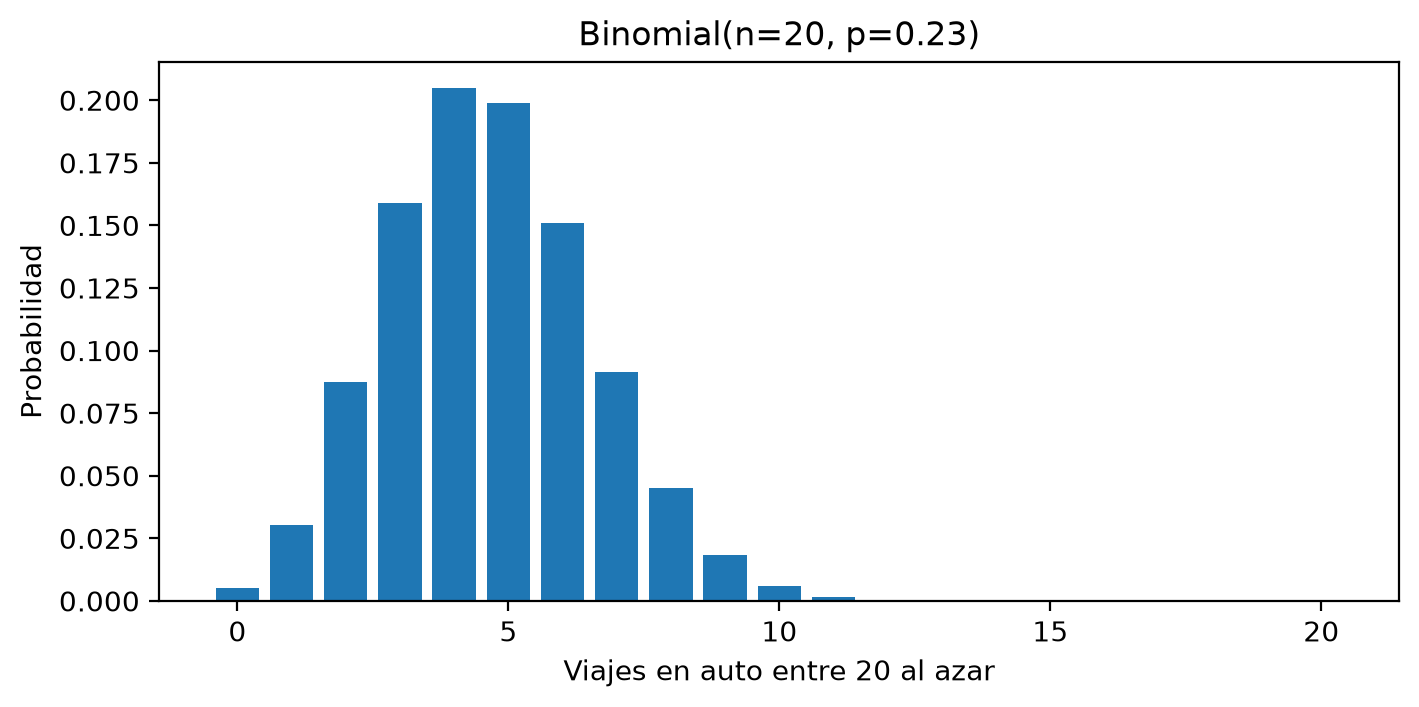

In [26]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})
viajes_modo = viajes.merge(modo_por_viaje, on="Viaje").merge(
    nombres_modo, left_on="ModoDifusion", right_on="ID")
p_auto = (viajes_modo["NombreModo"] == "Auto").mean()
print("Fracción de viajes en auto:", round(p_auto, 3))

k = np.arange(0, 21)
fig, ax = plt.subplots(figsize=(8, 3.5))
# stats.binom.pmf: la probabilidad de exactamente k éxitos
ax.bar(k, stats.binom.pmf(k, 20, p_auto))
ax.set(xlabel="Viajes en auto entre 20 al azar", ylabel="Probabilidad",
      title=f"Binomial(n=20, p={p_auto:.2f})")
plt.show()

Cada barra es la fórmula evaluada en un $k$. Para $k = 5$, a mano y con SciPy:

In [27]:
from math import comb

# comb(20, 5): de cuántas formas se eligen 5 viajes entre 20
a_mano = comb(20, 5) * p_auto**5 * (1 - p_auto)**15
print(f"a mano:  {comb(20, 5)} x {p_auto:.3f}^5 x {1 - p_auto:.3f}^15 = {a_mano:.4f}")
print(f"con SciPy: {stats.binom.pmf(5, 20, p_auto):.4f}")

a mano:  15504 x 0.233^5 x 0.767^15 = 0.1990
con SciPy: 0.1990


Volvamos a los hogares y a su ingreso:

In [28]:
h = hogares.dropna(subset=["IngresoHogar", "NumVeh", "Factor"]).copy()
h["tiene_auto"] = (h["NumVeh"] > 0).astype(int)
ingreso = h["IngresoHogar"] / 1e6

print("hogares:", len(h))
print("fracción con auto (ponderada):", round(np.average(h["tiene_auto"], weights=h["Factor"]), 3))

hogares: 18264
fracción con auto (ponderada): 0.404


Primero, lo que **no** hay que hacer: ajustar la recta de siempre sobre un 0/1.

In [29]:
# La recta de mínimos cuadrados sobre un sí o no (ponderada)
recta = sm.WLS(h["tiene_auto"], sm.add_constant(ingreso), weights=h["Factor"]).fit()
a, b = recta.params
print(f"recta: {a:.2f} + {b:.2f} · ingreso")
print(f"predicción para 5 millones: {a + b * 5:.2f}")

recta: 0.24 + 0.23 · ingreso
predicción para 5 millones: 1.39


Predice 1,39: una "probabilidad" mayor que 1, y con ingresos bajos daría valores cercanos a 0 o negativos. La recta no respeta que la respuesta vive entre 0 y 1. La **regresión logística** arregla eso pasando la recta por una curva en forma de S, la sigmoide:

$$P(y = 1 \mid x) = \frac{1}{1 + e^{-(a + b\,x)}}$$

donde $P(y=1 \mid x)$ es la probabilidad de un sí dado $x$, $a + b\,x$ es la misma recta de siempre (ahora en escala de **log-chances**, el logaritmo de sí/no), y $e^{b}$ dice cuánto se multiplican las chances de un sí por cada unidad de $x$. Por muy grande o chica que sea la recta, la curva queda entre 0 y 1. En statsmodels es un modelo lineal generalizado con familia binomial (`sm.GLM`), que acepta los pesos:

In [30]:
logistica = sm.GLM(
    h["tiene_auto"], sm.add_constant(ingreso),
    family=sm.families.Binomial(),   # la respuesta es un sí o no
    freq_weights=h["Factor"],         # el factor de expansión
).fit()

a, b = logistica.params
print(f"a = {a:.2f}, b = {b:.2f}")
print(f"odds ratio e^b = {np.exp(b):.1f}: cada millón multiplica las chances de tener auto por {np.exp(b):.1f}")

a = -1.87, b = 2.18
odds ratio e^b = 8.9: cada millón multiplica las chances de tener auto por 8.9


El mismo summary de siempre, con las mismas columnas: **coef**, **std err**, **z** (el $t$ cuando la distribución es la normal, porque $n$ es grande) y **P>|z|**. Se lee igual que en la sección 6:

In [31]:
logistica.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
const,-1.8691,0.003,-620.273,0.000,-1.875,-1.863
IngresoHogar,2.1809,0.004,541.553,0.000,2.173,2.189


Con una letra chica: el error estándar es minúsculo y $z$ enorme porque `freq_weights` hace que statsmodels cuente cada hogar tantas veces como su factor de expansión, como si la muestra fueran los dos millones de hogares de la ciudad y no los 18 mil encuestados. Es el supuesto de independencia de la sección 6, roto por la ponderación: los coeficientes están bien, pero los $t$ y $p$ con factores de expansión requieren un cuidado que queda fuera del módulo.

In [32]:
def sigmoide(x):
    return 1 / (1 + np.exp(-(a + b * x)))

for v in [0.3, 0.5, 1, 2, 3]:
    print(f"ingreso {v} M$: P(tiene auto) = {sigmoide(v):.2f}")
print(f"ingreso con P = 0,5: {-a / b:.2f} M$")

ingreso 0.3 M$: P(tiene auto) = 0.23
ingreso 0.5 M$: P(tiene auto) = 0.31
ingreso 1 M$: P(tiene auto) = 0.58
ingreso 2 M$: P(tiene auto) = 0.92
ingreso 3 M$: P(tiene auto) = 0.99
ingreso con P = 0,5: 0.86 M$


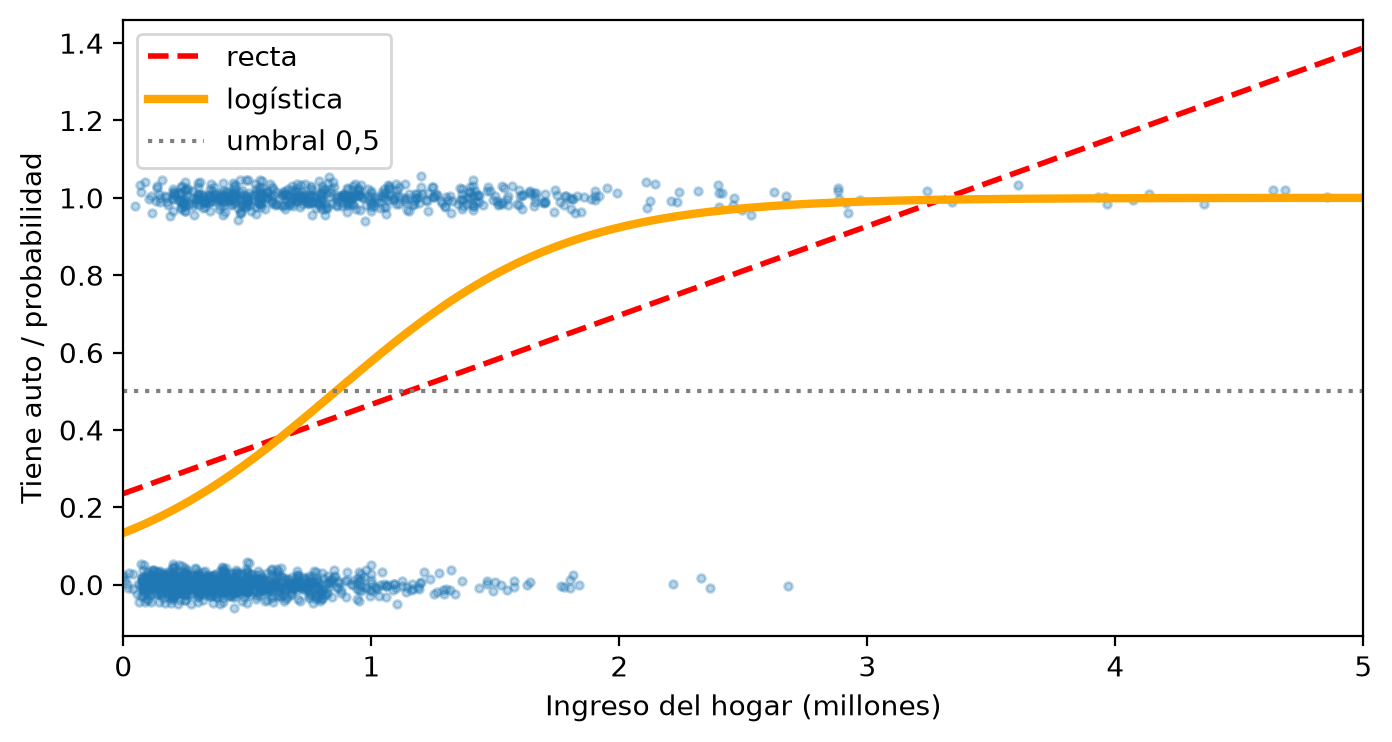

In [33]:
# Los hogares (una muestra de 1500, con un poco de ruido vertical
# para que los 0 y los 1 no se tapen), la recta y la curva
muestra_h = h.sample(1500, random_state=5)
grilla = np.linspace(0, 5, 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(muestra_h["IngresoHogar"] / 1e6,
           muestra_h["tiene_auto"] + rng.normal(0, 0.02, len(muestra_h)), s=8, alpha=0.3)
ax.plot(grilla, recta.params.iloc[0] + recta.params.iloc[1] * grilla, "r--", lw=2, label="recta")
ax.plot(grilla, sigmoide(grilla), color="orange", lw=3, label="logística")
ax.axhline(0.5, color="gray", ls=":", label="umbral 0,5")
ax.set(xlim=(0, 5), xlabel="Ingreso del hogar (millones)", ylabel="Tiene auto / probabilidad")
ax.legend()
plt.show()

La lectura del coeficiente es multiplicativa, como en el modelo en log de la clase 4: $e^{b} \approx 8{,}9$ significa que cada millón adicional multiplica las **chances** (sí contra no) de tener auto por casi 9. Y la curva se lee directo en probabilidades: 0,23 con 300 mil pesos, 0,58 con un millón, 0,92 con dos.

### Clasificar

**Objetivo:** convertir la probabilidad en una decisión, y medir cuántas veces acierta.

Un **clasificador** decide sí o no. El más simple: predecir "tiene auto" cuando la probabilidad supera 0,5 (aquí, desde 0,86 millones de ingreso). La tabla de contingencia de lo real contra lo predicho es la **matriz de confusión**, y la fracción de aciertos, la **exactitud**:

In [34]:
h["prob"] = logistica.predict(sm.add_constant(ingreso))
h["prediccion"] = (h["prob"] >= 0.5).astype(int)

# La matriz de confusión: crosstab de lo real contra lo predicho
print(pd.crosstab(h["tiene_auto"], h["prediccion"], rownames=["real"], colnames=["predicho"]))

exactitud = (h["prediccion"] == h["tiene_auto"]).mean()
base = 1 - h["tiene_auto"].mean()
print(f"exactitud: {exactitud:.3f} | decir siempre \"no\": {base:.3f}")

predicho     0     1
real                
0         9777  1297
1         4092  3098
exactitud: 0.705 | decir siempre "no": 0.606


Acierta el 70% de los hogares, contra el 61% que se obtiene sin modelo alguno diciendo siempre "no tiene" (la clase mayoritaria). Esa comparación con la **base** es obligatoria para cualquier clasificador: una exactitud alta puede ser solo el reflejo de una clase muy frecuente. La matriz de confusión muestra dónde se equivoca: hogares con auto que el modelo declara sin auto, y al revés. Mover el umbral cambia ese balance, y elegirlo depende de cuál error cuesta más. Esto, la logística con varias variables y sus métricas, es el tema de la clase 7.

## 9. Ejercicio 

Con los datos de su proyecto (o con la EOD si aún no los tiene):

1. Calcule el error estándar y el intervalo de confianza del 95% de la media de su variable objetivo.
2. Ajuste una regresión simple con statsmodels y lea la fila completa de su variable: coeficiente, error estándar, t, valor p e intervalo. ¿Qué concluye?
3. Obtenga el intervalo de la pendiente por bootstrap y compárelo con el de statsmodels.
4. Cuente cuántas correlaciones probó en su EDA y aplique la regla de las comparaciones múltiples.
5. Si su variable objetivo es un sí o no, ajuste una regresión logística con una variable, y compare su exactitud con la de predecir siempre la clase mayoritaria.

Todo esto es material directo para el primer análisis exploratorio, que se entrega el lunes 15.

In [35]:
# Su solución


---

**Próxima clase (jueves 10-sep):** regresión lineal en profundidad: supuestos, diagnósticos con los residuos y cómo evaluar un modelo fuera de la muestra. Recuerde: el primer análisis exploratorio se entrega el lunes 15 de septiembre.